In [1]:
from __future__ import print_function
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torchvision
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torchvision.transforms as transforms

from torch.autograd import Variable
import pylab
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Standard MNIST preprocessing
transform = transforms.Compose([
    transforms.Resize(32), # Resizing to 32x32 often works better with DCGAN layers
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [2]:
num_gpu = 1 if torch.cuda.is_available() else 0
# load the models
from dcgan import Discriminator, Generator

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# 2. Load the weights using that device
D.load_state_dict(torch.load('weights/netD_epoch_99.pth', map_location=device))
G.load_state_dict(torch.load('weights/netG_epoch_99.pth', map_location=device))

# 3. Move the models to the device
D = D.to(device)
G = G.to(device)

Running on: cpu


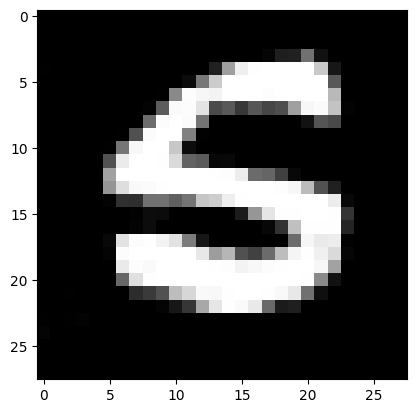

tensor([0.0926], grad_fn=<SqueezeBackward1>)  this shows that the image is mostly generator created (not a real dataset one)


In [4]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
print(D(image_generated), " this shows that the image is mostly generator created (not a real dataset one)")

## training the inverese G+ 

z is the random data created in the latent space, G(z) + noise is the input to G*, whose output is z*, 

z* = G*(G(z) + noise)  

loss = ||z*  - z||^2

In [5]:
# defiing the G* architecture

class InverseGenerator(nn.Module):
    def __init__(self, ngpu, nc=1, nz=100, ndf=64):
        super(InverseGenerator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input is (nc) x 28 x 28
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf) x 14 x 14
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*2) x 7 x 7
            # We use a kernel of 3 here to handle the odd 7x7 dimension transition
            nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False), 
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, nz, 4, 1, 0, bias=False),
            # Final output is (nz) x 1 x 1
        )

    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output

In [6]:
G_inv = InverseGenerator(ngpu=1).to(device)
G_inv.train()
optimizer = optim.Adam(G_inv.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.MSELoss()
epochs = 5000
batch_size = 512
latent_size = 100
noise_factor = 0.05

## training loop (ran on colab)

In [ ]:
# print("Starting Training Loop...")

# for epoch in range(epochs):
#     optimizer.zero_grad()
    
#     # 1. Generate a FRESH batch of random z for this epoch
#     z_true = torch.randn(batch_size, latent_size, 1, 1).to(device)
        
#     # 2. Generate perfect images from z (using no_grad to save memory!)
#     with torch.no_grad():
#         fake_images = G(z_true)
        
#     # 3. Add synthetic corruption (noise)
#     noise = torch.randn_like(fake_images) * noise_factor
#     corrupted_images = fake_images + noise
    
#     # 4. Pass the corrupted images through your Inverse Generator
#     z_recovered = G_inv(corrupted_images)
    
#     # 5. Calculate MSE Loss: |z* - z|^2
#     loss = criterion(z_recovered, z_true)
    
#     # 6. Backpropagation and optimization step
#     loss.backward()
#     optimizer.step()
    
#     # 7. Print progress every 250 epochs
#     if epoch % 250 == 0 or epoch == epochs - 1:
#         print(f"Epoch [{epoch}/{epochs}] | MSE Loss: {loss.item():.6f}")
        
#     # 8. Manually delete variables to free memory
#     del z_true, fake_images, noise, corrupted_images, z_recovered, loss
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# print("Training Complete!")

Starting Training Loop...
Epoch [0/5000] | MSE Loss: 1.172190
Epoch [250/5000] | MSE Loss: 0.930741
Epoch [500/5000] | MSE Loss: 0.922145


: 

## load the model and run it 

In [7]:
G_inv.eval()
G_inv.load_state_dict(torch.load('weights/G_inv_weights.pth', map_location=device))

<All keys matched successfully>

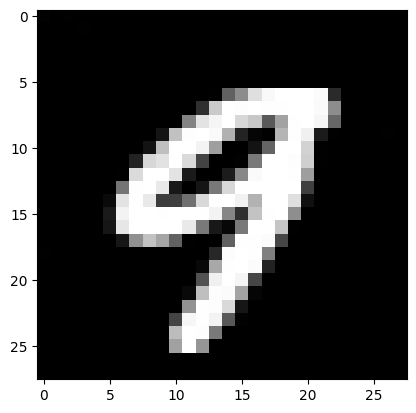

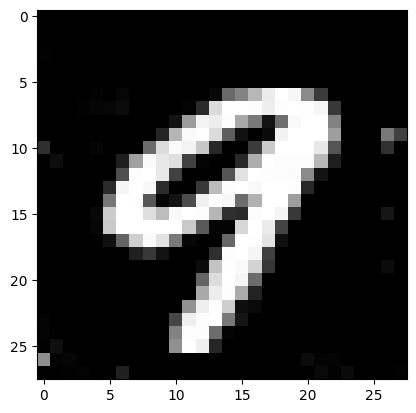

In [8]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
vec_generated = G_inv(image_generated)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
inverse_image_generated = G(vec_generated).cpu().detach().numpy().reshape(28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
plt.imshow(inverse_image_generated, cmap='gray')
plt.show()

In [11]:
# ============================================================
# Projected Gradient Descent on Range(G) - Algorithm Implementation
# Input: A, y, G, G_inv (G†), step size η
# ============================================================

def pgd_on_range_G(A, y, G, G_inv, eta=0.1, T=500, device='cpu', verbose=True):
    """
    Projected Gradient Descent on Range(G).
    
    Args:
        A       : Measurement matrix (m x n), e.g. random Gaussian
        y       : Observations (m,), y = Ax*
        G       : Generator (maps z -> image)
        G_inv   : Inverse Generator / G† (maps image -> z)
        eta     : Step size (1/beta)
        T       : Number of iterations
        device  : 'cpu' or 'cuda'
        verbose : Print loss every 50 steps
    
    Returns:
        x_hat   : Recovered image in Range(G), shape (1, 1, 28, 28)
    """
    G.eval()
    G_inv.eval()

    # Flatten dims for linear algebra: image is (1, 28, 28) -> n = 784
    n = 28 * 28

    # ── Step 1: x0 = A^T y ──────────────────────────────────
    # A : (m, n), y : (m,)  =>  A^T y : (n,)
    with torch.no_grad():
        x_t = (A.T @ y)                           # shape: (n,)
        x_t = x_t.to(device)

    x_t = x_t.requires_grad_(False)

    loss_history = []

    for t in range(T):
        with torch.no_grad():
            # ── Step 3: Gradient step ────────────────────────
            # w_t = x_t - η * A^T(A x_t - y)
            residual = A @ x_t - y                # shape: (m,)
            grad     = A.T @ residual             # shape: (n,)
            w_t      = x_t - eta * grad           # shape: (n,)

            # ── Step 4: Project onto Range(G) ────────────────
            # Reshape w_t to image format for G_inv
            w_img = w_t.view(1, 1, 28, 28)        # (1, nc, H, W)

            # G†(w_t) -> latent code
            z_t   = G_inv(w_img)                  # (1, 100, 1, 1)

            # G(G†(w_t)) -> projection back onto Range(G)
            x_next = G(z_t)                       # (1, 1, 28, 28)

            # Flatten for next iteration
            x_t    = x_next.view(n)               # (n,)

            # Track reconstruction loss  ||Ax_t - y||^2
            loss = torch.norm(A @ x_t - y).item() ** 2
            loss_history.append(loss)

        if verbose and (t % 50 == 0 or t == T - 1):
            print(f"Iter [{t:>4}/{T}] | ||Ax - y||² = {loss:.6f}")

    x_hat = x_next  # final estimate in Range(G)
    return x_hat, loss_history

Iter [   0/1000] | ||Ax - y||² = 531.429529
Iter [  50/1000] | ||Ax - y||² = 462.408797
Iter [ 100/1000] | ||Ax - y||² = 462.200792
Iter [ 150/1000] | ||Ax - y||² = 462.200792
Iter [ 200/1000] | ||Ax - y||² = 462.200792
Iter [ 250/1000] | ||Ax - y||² = 462.200792
Iter [ 300/1000] | ||Ax - y||² = 462.200792
Iter [ 350/1000] | ||Ax - y||² = 462.200874
Iter [ 400/1000] | ||Ax - y||² = 462.200792
Iter [ 450/1000] | ||Ax - y||² = 462.200792
Iter [ 500/1000] | ||Ax - y||² = 462.200792
Iter [ 550/1000] | ||Ax - y||² = 462.200792
Iter [ 600/1000] | ||Ax - y||² = 462.200792
Iter [ 650/1000] | ||Ax - y||² = 462.200792
Iter [ 700/1000] | ||Ax - y||² = 462.200792
Iter [ 750/1000] | ||Ax - y||² = 462.200874
Iter [ 800/1000] | ||Ax - y||² = 462.200792
Iter [ 850/1000] | ||Ax - y||² = 462.200792
Iter [ 900/1000] | ||Ax - y||² = 462.200792
Iter [ 950/1000] | ||Ax - y||² = 462.200792
Iter [ 999/1000] | ||Ax - y||² = 462.200792


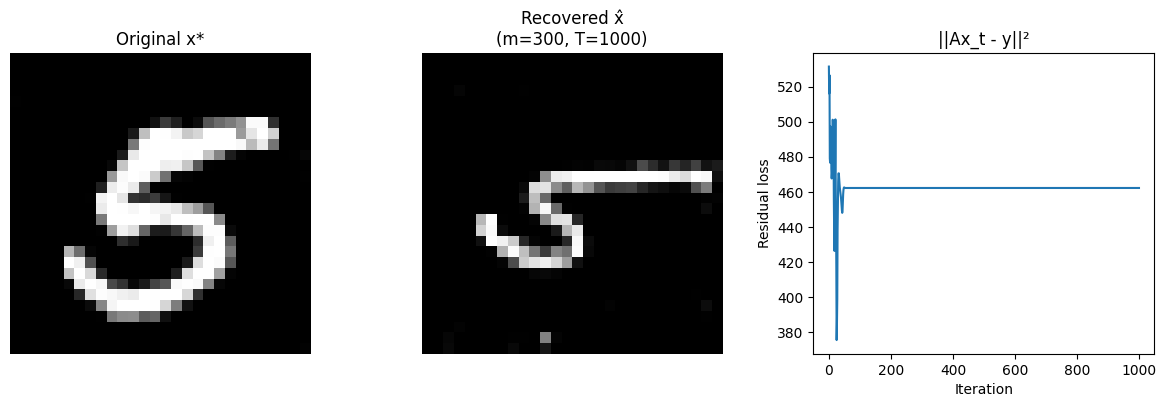


Reconstruction error ||x̂ - x*|| = 22.6123

Relative Reconstruction error ||x̂ - x*|| = 0.8461


In [ ]:
# ============================================================
# Demo: Compress a generated image and recover it
# ============================================================

m          = 300        # number of measurements  (m << 784)
n          = 28 * 28    # signal dimension
eta        = 0.05       # step size  (tune this if it diverges)
T          = 500        # iterations

# ── 1. Create a ground-truth image from G ───────────────────
with torch.no_grad():
    z_true       = torch.randn(1, 100, 1, 1).to(device)
    x_true_img   = G(z_true)                         # (1,1,28,28)  in [-1,1]
    x_true       = x_true_img.view(n).to(device)     # flatten to (784,)

# ── 2. Build random Gaussian measurement matrix A ───────────
torch.manual_seed(42)
A = (torch.randn(m, n) / (m ** 0.5)).to(device)     # (m, n)

# ── 3. Simulate observations  y = Ax* ───────────────────────
with torch.no_grad():
    y = A @ x_true                                   # (m,)

# ── 4. Run the algorithm ─────────────────────────────────────
x_hat, losses = pgd_on_range_G(A, y, G, G_inv, eta=eta, T=T, device=device)

# ── 5. Visualise results ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x_true_img.cpu().detach().numpy().reshape(28, 28), cmap='gray')
axes[0].set_title('Original x*')
axes[0].axis('off')

axes[1].imshow(x_hat.cpu().detach().numpy().reshape(28, 28), cmap='gray')
axes[1].set_title(f'Recovered x̂\n(m={m}, T={T})')
axes[1].axis('off')

axes[2].plot(losses)
axes[2].set_title('||Ax_t - y||²')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Residual loss')

plt.tight_layout()
plt.show()

# ── 6. Pixel-space reconstruction error ──────────────────────
with torch.no_grad():
    err = torch.norm(x_hat.view(n) - x_true).item()
print(f"\nReconstruction error ||x̂ - x*|| = {err:.4f}")
print(f"\nRelative Reconstruction error ||x̂ - x*|| = {err / torch.norm(x_true).item():.4f}")

In [15]:
# G_inv sanity check: G(G_inv(G(z))) should ≈ G(z)
G.eval(); G_inv.eval()
errors = []
with torch.no_grad():
    for _ in range(200):
        z   = torch.randn(1, 100, 1, 1).to(device)
        img = G(z)                        # original generated image
        z_r = G_inv(img)                  # invert it
        img_r = G(z_r)                    # re-generate from recovered z
        err = torch.norm(img_r - img).item()
        errors.append(err)

print(f"G(G_inv(G(z))) mean pixel error: {np.mean(errors):.4f} ± {np.std(errors):.4f}")
# Target: < 0.05. If > 0.2, G_inv is the bottleneck — retrain it.

G(G_inv(G(z))) mean pixel error: 8.3777 ± 2.5833
